# TP1 — Análisis de Series Temporales
**Materia:** Análisis de Series Temporales — Maestría en Ciencia de Datos, Universidad Austral  
**Docente:** Rodrigo Del Rosso

---

## Series analizadas

| Serie | Descripción | Tipo esperado |
|---|---|---|
| **S&P 500** | Índice bursátil de las 500 principales empresas de EE.UU. | No estacionaria (tendencia) |
| **CBOE VIX** | Índice de volatilidad implícita del mercado ("índice del miedo") | Estacionaria (mean-reverting) |

La elección de estas dos series no es casual: representan **dos comportamientos opuestos** en términos de estacionariedad, lo que permite contrastar los conceptos teóricos de manera clara.

---
**Puntos cubiertos:** 2 · 3 · 4 · 5 · 6 · 7 · 8 · 9 · 10 · 11

## 0. Librerías

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')
print('OK')

OK


---
## 1. Carga y limpieza de datos

Cada archivo tiene un formato distinto según el idioma de Investing.com:
- **S&P 500:** formato inglés → `Date` en MM/DD/YYYY, separador de miles con coma (`6,582.69`)
- **VIX:** formato español → `Fecha` en DD.MM.YYYY, separador decimal con coma (`115,33`)

In [6]:
# ── S&P 500 ──────────────────────────────────────────────────────────────
sp = pd.read_csv('S&P 500 Historical Data.csv')
sp['Date']  = pd.to_datetime(sp['Date'], format='%m/%d/%Y')
sp['SP500'] = sp['Price'].astype(str).str.replace(',', '').astype(float)
sp = sp[['Date', 'SP500']].sort_values('Date').set_index('Date')

# ── VIX ──────────────────────────────────────────────────────────────────
# El CSV viene en locale español: coma como decimal, fecha DD.MM.YYYY
vix = pd.read_csv('Datos históricos del CBOE Vix Volatility.csv')
vix['Date'] = pd.to_datetime(vix['Fecha'], format='%d.%m.%Y')
vix['VIX']  = vix['Último'].astype(str).str.replace(',', '.').astype(float)
vix = vix[['Date', 'VIX']].sort_values('Date').set_index('Date')

# ── Resumen ───────────────────────────────────────────────────────────────
for nombre, df in [('S&P 500', sp), ('VIX', vix)]:
    col = df.columns[0]
    print(f"{nombre:8s}: {len(df):4d} obs | "
          f"{df.index.min().date()} → {df.index.max().date()} | "
          f"min={df[col].min():.2f}  max={df[col].max():.2f}  media={df[col].mean():.2f}")

S&P 500 :  274 obs | 2025-03-03 → 2026-04-02 | min=4982.77  max=6978.60  media=6383.25
VIX     :  279 obs | 2025-03-03 → 2026-04-02 | min=81.89  max=170.92  media=103.24


---
## Punto 2 — Series originales y estacionariedad

### Marco teórico: estacionariedad

Una serie $\{Y_t\}$ es **débilmente estacionaria** si cumple:

$$E[Y_t] = \mu \quad \forall t \qquad \text{(media constante)}$$
$$\text{Var}(Y_t) = \sigma^2 < \infty \quad \forall t \qquad \text{(varianza constante)}$$
$$\text{Cov}(Y_t,\, Y_{t-k}) = \gamma(k) \quad \forall t \qquad \text{(covarianza depende solo del rezago } k \text{)}$$

**¿Por qué importa?** Los modelos ARIMA requieren estacionariedad. Ajustar un ARIMA sobre una serie con tendencia produce parámetros espúreos e inferencias incorrectas.

### Las dos series como caso de estudio

| | S&P 500 | VIX |
|---|---|---|
| **Intuición** | Precio de activo → tiende a crecer indefinidamente | Índice de "miedo" → siempre regresa a su media histórica |
| **Media** | Creciente (no constante) | Estable alrededor de un valor fijo |
| **Mecanismo** | Random walk / tendencia estocástica | Mean-reversion: alta volatilidad → mercado se calma → vuelve a la media |
| **Estacionaria** | ❌ No | ✅ Sí |

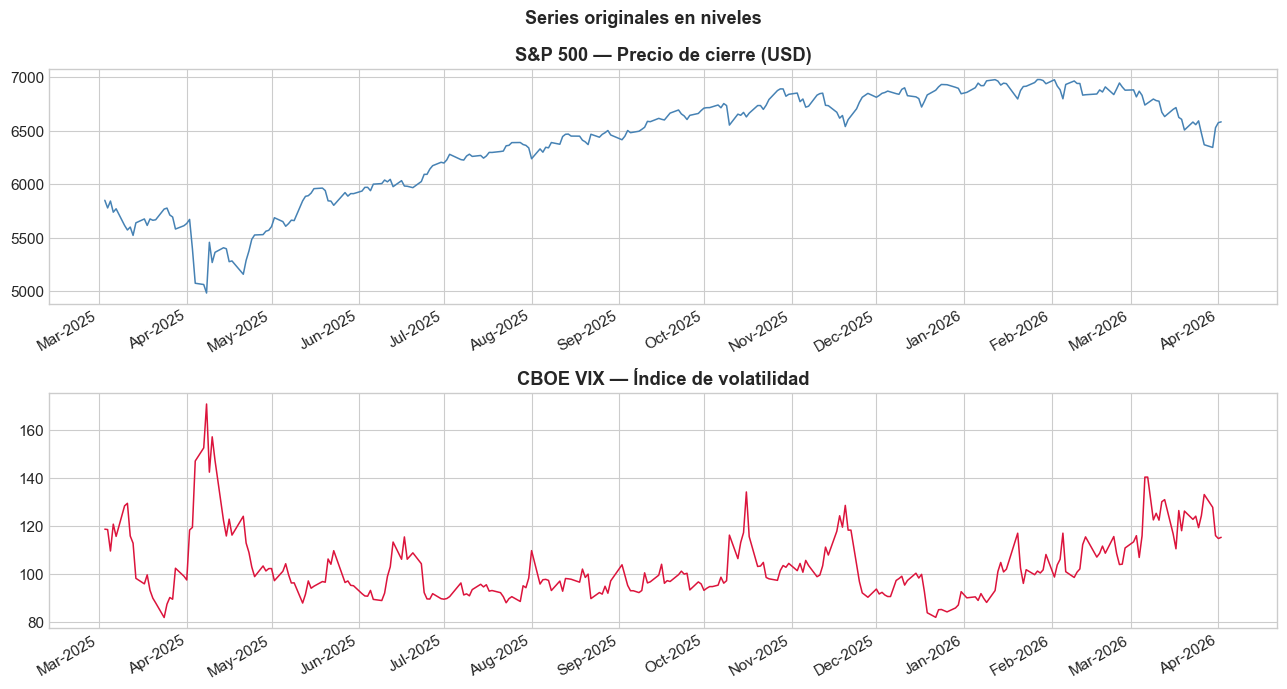

In [7]:
# ── Gráfico de series originales en niveles ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

configs = [
    (sp,  'SP500', 'S&P 500 — Precio de cierre (USD)',    'steelblue'),
    (vix, 'VIX',   'CBOE VIX — Índice de volatilidad',    'crimson'),
]

for ax, (df, col, title, color) in zip(axes, configs):
    ax.plot(df.index, df[col], color=color, linewidth=1.1)
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Series originales en niveles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observación visual

Con solo mirar las series ya se puede intuir la diferencia:

- **S&P 500:** la serie sube progresivamente. La media de los primeros meses es claramente distinta a la de los últimos. → **no estacionaria**.
- **VIX:** la serie sube y baja alrededor de un valor central. No hay una tendencia sostenida. → **candidata a estacionaria** (se confirmará formalmente con tests).

In [ ]:
# ── Estadísticas descriptivas por mitades ─────────────────────────────────
# Dividimos cada serie en dos mitades y comparamos media y desvío.
# Si la serie es estacionaria, ambas mitades deberían tener estadísticas similares.
""
print(f"{'Serie':<10} {'Mitad':<10} {'Media':>10} {'Desvío':>10}")
print("-" * 45)
for nombre, df, col in [('S&P 500', sp, 'SP500'), ('VIX', vix, 'VIX')]:
    n = len(df)
    primera = df[col].iloc[:n//2]
    segunda = df[col].iloc[n//2:]
    print(f"{nombre:<10} {'Primera':<10} {primera.mean():>10.2f} {primera.std():>10.2f}")
    print(f"{'':10} {'Segunda':<10} {segunda.mean():>10.2f} {segunda.std():>10.2f}")
    print()

Serie      Mitad           Media     Desvío
---------------------------------------------
S&P 500    Primera       5982.80     394.69
           Segunda       6783.71     133.90

VIX        Primera        101.49      14.56
           Segunda        104.98      12.44



### Estadísticas móviles (media y desvío rodante)

Una herramienta visual clave para analizar estacionariedad es graficar la **media móvil** y la **desviación estándar móvil** sobre ventanas de tiempo.

- Si la media móvil es **constante** → evidencia de estacionariedad
- Si la media móvil tiene **tendencia** → no estacionaria
- Si la desviación móvil es **constante** → homocedasticidad (varianza constante)

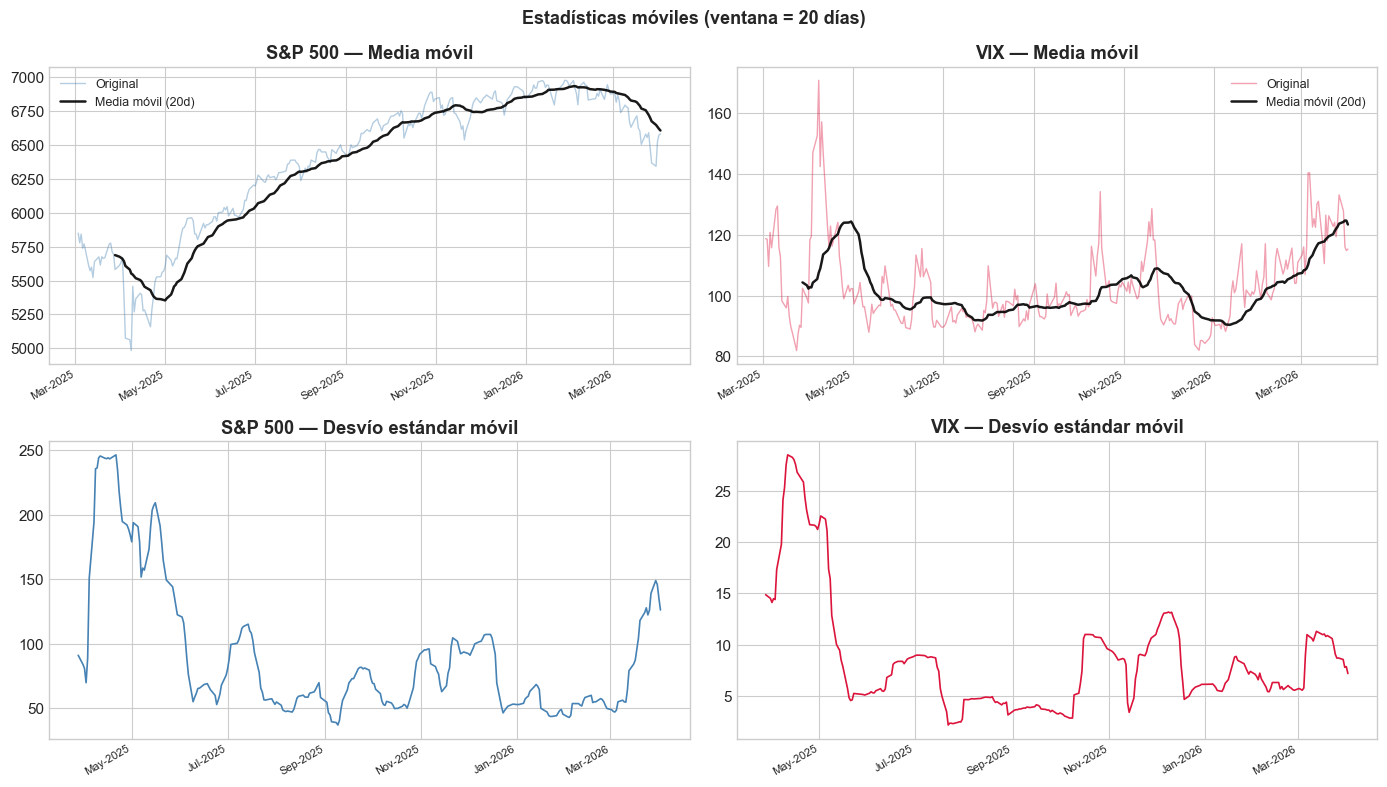

In [9]:
# ── Media y desvío rodante ────────────────────────────────────────────────
ventana = 20  # ~1 mes de días hábiles

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col_idx, (df, col, nombre, color) in enumerate([
    (sp,  'SP500', 'S&P 500', 'steelblue'),
    (vix, 'VIX',   'VIX',     'crimson'),
]):
    serie = df[col].dropna()
    rm  = serie.rolling(ventana).mean()
    rstd = serie.rolling(ventana).std()

    # Media móvil
    ax = axes[0, col_idx]
    ax.plot(serie.index, serie, color=color,   alpha=0.4, lw=1,   label='Original')
    ax.plot(rm.index,   rm,    color='black',  alpha=0.9, lw=1.8, label=f'Media móvil ({ventana}d)')
    ax.set_title(f'{nombre} — Media móvil', fontweight='bold')
    ax.legend(fontsize=9)

    # Desvío estándar móvil
    ax2 = axes[1, col_idx]
    ax2.plot(rstd.index, rstd, color=color, lw=1.2)
    ax2.set_title(f'{nombre} — Desvío estándar móvil', fontweight='bold')

    for a in [ax, ax2]:
        a.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
        plt.setp(a.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Estadísticas móviles (ventana = 20 días)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación

**S&P 500:**
- La media móvil tiene pendiente positiva clara → **media no constante** → no estacionaria.
- El desvío móvil también varía, lo que indica **heterocedasticidad** (varianza no constante).

**VIX:**
- La media móvil oscila alrededor de un valor central sin tendencia sistemática → evidencia de **media estable**.
- El desvío móvil varía pero no tiene una tendencia clara.

### Diferenciación del S&P 500

Para eliminar la raíz unitaria del S&P 500 se aplica la **primera diferencia logarítmica** (log-retorno):

$$r_t = \ln\!\left(\frac{Y_t}{Y_{t-1}}\right) = \Delta \ln(Y_t)$$

Esta transformación tiene dos ventajas:
1. Elimina la tendencia estocástica (raíz unitaria)
2. Estabiliza la varianza (los retornos son aproximadamente homocedásticos)

Para el **VIX**, que ya es estacionario, se trabaja directamente en niveles. No es necesario diferenciar.

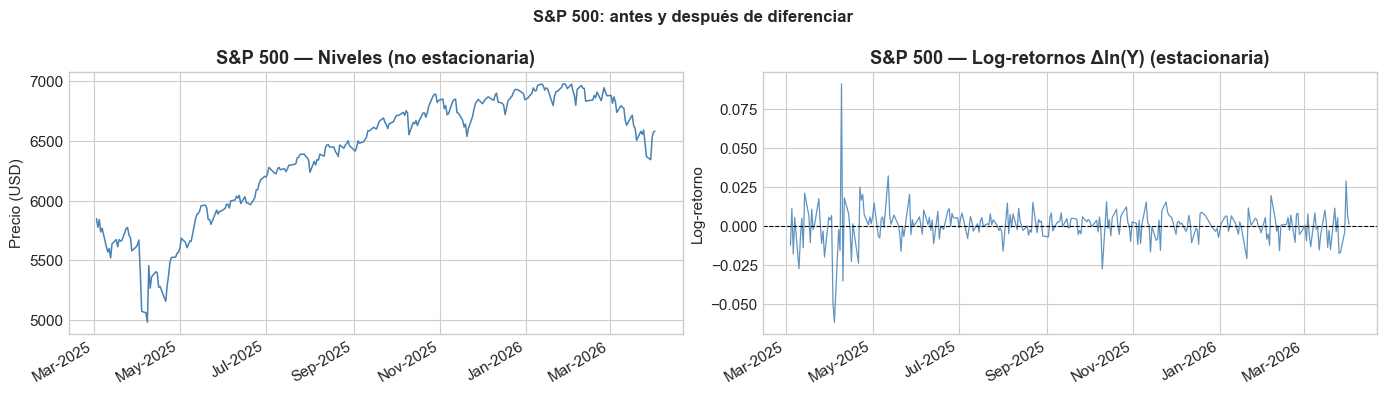

S&P 500 en niveles  → media móvil tiene tendencia: SÍ
S&P 500 log-retorno → media ≈ 0.00043  |  std = 0.01156


In [10]:
# ── Transformación del S&P 500 ────────────────────────────────────────────
sp_ret = np.log(sp['SP500']).diff().dropna().rename('SP500_ret')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sp['SP500'],  color='steelblue', lw=1.1)
axes[0].set_title('S&P 500 — Niveles (no estacionaria)', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')

axes[1].plot(sp_ret, color='steelblue', lw=0.9, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('S&P 500 — Log-retornos Δln(Y) (estacionaria)', fontweight='bold')
axes[1].set_ylabel('Log-retorno')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('S&P 500: antes y después de diferenciar', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"S&P 500 en niveles  → media móvil tiene tendencia: SÍ")
print(f"S&P 500 log-retorno → media ≈ {sp_ret.mean():.5f}  |  std = {sp_ret.std():.5f}")

---
## Punto 3 — FAS, FAC y FACP

### Marco teórico

Estas tres funciones son las **herramientas de diagnóstico** más importantes en el análisis de series temporales.

---
#### Función de Autocovarianza Simple (FAS)

$$\hat{\gamma}(k) = \frac{1}{T} \sum_{t=k+1}^{T} (Y_t - \bar{Y})(Y_{t-k} - \bar{Y})$$

Mide la **covarianza** entre la serie y su propia versión rezagada $k$ períodos. No está normalizada → sus valores dependen de la escala de la serie.

---
#### Función de Autocorrelación (FAC / ACF)

$$\hat{\rho}(k) = \frac{\hat{\gamma}(k)}{\hat{\gamma}(0)} \in [-1,\, 1]$$

Es la FAS **normalizada**. Las bandas punteadas en los gráficos son el intervalo de confianza al 95% bajo $H_0$: ruido blanco:

$$\pm \frac{1.96}{\sqrt{T}}$$

Rezagos que superen las bandas indican **autocorrelación estadísticamente significativa**.

**Cómo leer la FAC:**
| Patrón | Proceso sugerido |
|---|---|
| Decaimiento lentísimo (casi no cae) | Serie no estacionaria / raíz unitaria |
| Se corta bruscamente en rezago $q$ | MA(q) |
| Decaimiento exponencial | AR(p) o ARMA |
| Todos los rezagos dentro de bandas | Ruido blanco |

---
#### Función de Autocorrelación Parcial (FACP / PACF)

La FACP en el rezago $k$ mide la correlación entre $Y_t$ e $Y_{t-k}$ **eliminando el efecto lineal** de los rezagos intermedios $Y_{t-1}, \ldots, Y_{t-k+1}$. En esencia, es la correlación "pura" a ese lag.

**Cómo leer la FACP:**
| Patrón | Proceso sugerido |
|---|---|
| Se corta bruscamente en rezago $p$ | AR(p) |
| Decaimiento gradual | MA(q) o ARMA |

---
#### Tabla resumen para identificación de modelos

| Modelo | FAC | FACP |
|:---:|:---:|:---:|
| **AR(p)** | Decae gradualmente | Se corta en $p$ |
| **MA(q)** | Se corta en $q$ | Decae gradualmente |
| **ARMA(p,q)** | Decae gradualmente | Decae gradualmente |
| **Ruido blanco** | Todos dentro de bandas | Todos dentro de bandas |

In [11]:
# ── Función para graficar FAS + FAC + FACP juntas ─────────────────────────
def plot_fas_fac_facp(serie, titulo, lags=30, color='steelblue'):
    """
    Grafica en una fila de 3 paneles:
      - FAS: Función de Autocovarianza (no normalizada)
      - FAC: Función de Autocorrelación (normalizada, con bandas)
      - FACP: Función de Autocorrelación Parcial (con bandas)
    """
    s = serie.dropna()
    T = len(s)
    mu = s.mean()

    # Cálculo manual de la FAS
    fas = [(1/T) * np.sum((s.values[k:] - mu) * (s.values[:T-k] - mu))
           for k in range(lags + 1)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # FAS
    axes[0].bar(range(lags + 1), fas, color=color, alpha=0.7, width=0.6)
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].set_title('FAS — Autocovarianza')
    axes[0].set_xlabel('Rezago k')
    axes[0].set_ylabel('γ(k)')

    # FAC
    plot_acf(s, lags=lags, ax=axes[1], color=color, alpha=0.05)
    axes[1].set_title('FAC — Autocorrelación')
    axes[1].set_xlabel('Rezago k')

    # FACP
    plot_pacf(s, lags=lags, ax=axes[2], color=color, alpha=0.05, method='ywm')
    axes[2].set_title('FACP — Autocorrelación Parcial')
    axes[2].set_xlabel('Rezago k')

    plt.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

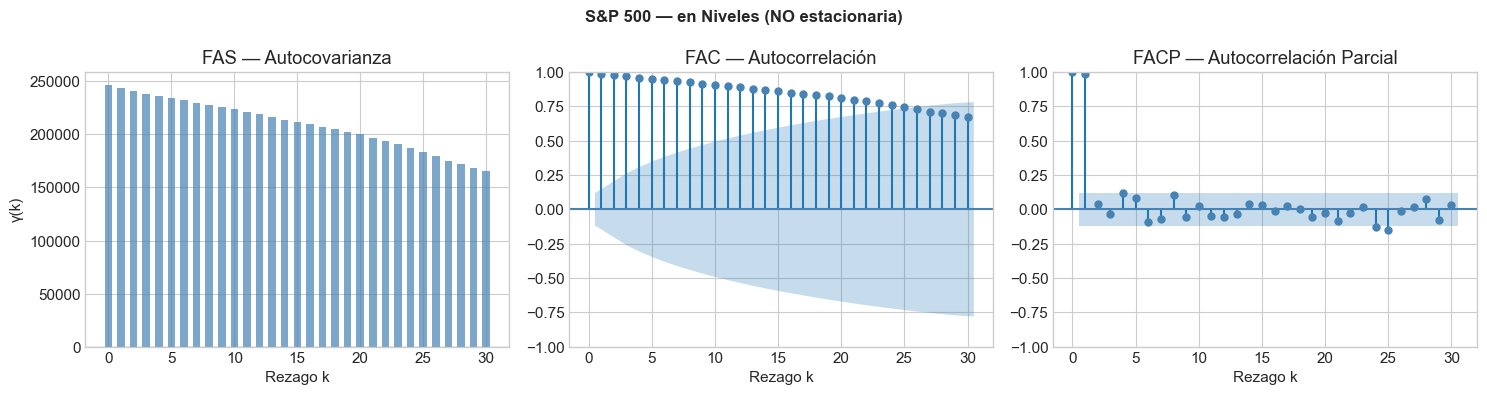

In [18]:
# ── S&P 500 en NIVELES ────────────────────────────────────────────────────
plot_fas_fac_facp(sp['SP500'], 'S&P 500 — en Niveles (NO estacionaria)', lags=30, color='steelblue')

**Diagnóstico — S&P 500 en niveles:**

- **FAS:** valores muy grandes y decrecen muy lentamente → la serie recuerda su historia durante muchos rezagos.
- **FAC:** decaimiento extremadamente lento. Prácticamente todos los rezagos son significativos y los primeros se acercan a 1. Este es el **patrón diagnóstico clásico de una raíz unitaria**. Una serie estacionaria nunca tendría este comportamiento.
- **FACP:** spike muy significativo en el rezago 1, luego se corta. Esto sugiere que el proceso puede aproximarse con un AR(1) en niveles — cuando ese coeficiente tiende a 1, el AR(1) se convierte en un random walk.

> **Regla práctica:** si la FAC no cae por debajo de las bandas de confianza en los primeros 10-15 rezagos, hay fuerte evidencia de raíz unitaria.

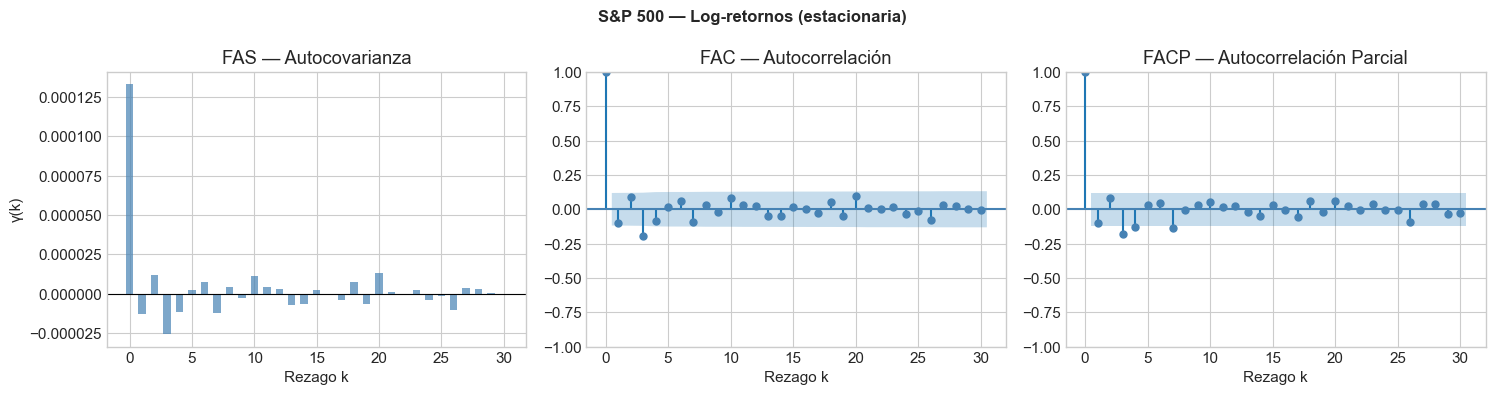

In [13]:
# ── S&P 500 en LOG-RETORNOS ───────────────────────────────────────────────
plot_fas_fac_facp(sp_ret, 'S&P 500 — Log-retornos (estacionaria)', lags=30, color='steelblue')

**Diagnóstico — S&P 500 log-retornos:**

- **FAC y FACP:** prácticamente todos los rezagos caen dentro de las bandas de confianza. La serie diferenciada se comporta como **ruido blanco**: no hay estructura de autocorrelación lineal detectable.
- **Implicancia:** los retornos del S&P 500 no son predecibles con modelos ARIMA simples. Esto es consistente con la hipótesis de mercados eficientes.

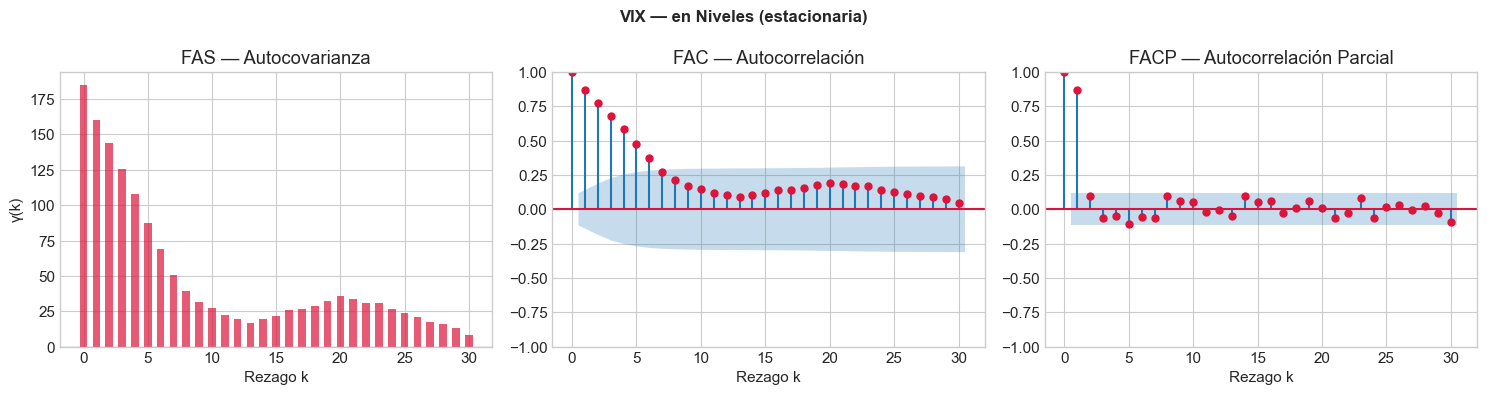

In [14]:
# ── VIX en NIVELES ────────────────────────────────────────────────────────
plot_fas_fac_facp(vix['VIX'], 'VIX — en Niveles (estacionaria)', lags=30, color='crimson')

**Diagnóstico — VIX en niveles:**

Aquí se observa el contraste más importante del análisis:

- **FAC:** el VIX muestra un decaimiento **gradual pero claro**: los primeros rezagos son significativos y luego la FAC cae dentro de las bandas. Este patrón es consistente con un proceso **AR estacionario**, donde la correlación con el pasado disminuye con el tiempo pero no dura indefinidamente.
- **FACP:** uno o pocos rezagos significativos al inicio, luego se cortan. Esto sugiere un proceso **AR(p)** de bajo orden → candidato a AR(1) o AR(2).

**Comparación fundamental:**
| | S&P 500 (niveles) | VIX (niveles) |
|---|---|---|
| FAC | Permanece cerca de 1 por 30+ rezagos | Decae y entra en las bandas |
| FACP | Spike en lag 1 (AR(1) con φ≈1) | Corte brusco (AR estacionario) |
| Diagnóstico | Raíz unitaria | Proceso estacionario |

> Esta diferencia visual en la FAC es **la señal más importante** para decidir si diferenciamos o no antes de ajustar un modelo ARIMA.

---
## Punto 4 — Tests de Raíces Unitarias

### Marco teórico

El análisis gráfico ofrece indicios, pero no certeza estadística. Los **tests de raíces unitarias** formalizan la hipótesis mediante un contraste estadístico.

---
#### Test ADF — Augmented Dickey-Fuller

Estima el modelo:
$$\Delta Y_t = \alpha + \beta t + \underbrace{(\rho - 1)}_{\delta} Y_{t-1} + \sum_{j=1}^{p} \phi_j \Delta Y_{t-j} + \varepsilon_t$$

$$H_0: \delta = 0 \;\text{(raíz unitaria, NO estacionaria)} \qquad H_1: \delta < 0 \;\text{(estacionaria)}$$

Se rechaza $H_0$ cuando el estadístico es **suficientemente negativo** (p-valor < 0.05).

---
#### Test KPSS — Kwiatkowski-Phillips-Schmidt-Shin

Las hipótesis son **las opuestas** al ADF:

$$H_0: \text{serie estacionaria} \qquad H_1: \text{raíz unitaria}$$

Se rechaza $H_0$ cuando el estadístico **supera** el valor crítico.

---
#### Interpretación conjunta ADF + KPSS

| ADF | KPSS | Conclusión |
|:---:|:---:|---|
| No rechaza $H_0$ | Rechaza $H_0$ | ✅ Raíz unitaria confirmada |
| Rechaza $H_0$ | No rechaza $H_0$ | ✅ Estacionaria confirmada |
| No rechaza $H_0$ | No rechaza $H_0$ | Evidencia débil / tendencia determinista |
| Rechaza $H_0$ | Rechaza $H_0$ | Resultado contradictorio |

In [19]:
# ── Función de tests ──────────────────────────────────────────────────────
def unit_root_tests(series_dict, label):
    print(f"\n{'═'*68}")
    print(f"  {label}")
    print(f"{'═'*68}")
    print(f"{'Serie':<14} {'Test':<6} {'Estadístico':>13} {'p-valor':>9} {'CV 5%':>9}  Conclusión")
    print(f"{'─'*68}")

    for nombre, s in series_dict.items():
        s = s.dropna()

        # ADF
        adf_stat, adf_p, _, _, adf_cv, _ = adfuller(s, autolag='AIC', regression='ct')
        adf_res = '❌ Raíz unitaria' if adf_p > 0.05 else '✅ Estacionaria'
        print(f"{nombre:<14} {'ADF':<6} {adf_stat:>13.4f} {adf_p:>9.4f} {adf_cv['5%']:>9.4f}  {adf_res}")

        # KPSS
        kp_stat, kp_p, _, kp_cv = kpss(s, regression='ct', nlags='auto')
        kp_res = '✅ Estacionaria' if kp_p > 0.05 else '❌ Raíz unitaria'
        print(f"{'':14} {'KPSS':<6} {kp_stat:>13.4f} {kp_p:>9.4f} {kp_cv['5%']:>9.4f}  {kp_res}")
        print(f"{'─'*68}")

# ── Tests sobre series en NIVELES ─────────────────────────────────────────
unit_root_tests(
    {'S&P 500':    sp['SP500'],
     'VIX':        vix['VIX']},
    label='NIVELES'
)

# ── Tests sobre S&P 500 diferenciado ──────────────────────────────────────
unit_root_tests(
    {'SP500_ret':  sp_ret},
    label='S&P 500 — LOG-RETORNOS (primera diferencia)'
)


════════════════════════════════════════════════════════════════════
  NIVELES
════════════════════════════════════════════════════════════════════
Serie          Test     Estadístico   p-valor     CV 5%  Conclusión
────────────────────────────────────────────────────────────────────
S&P 500        ADF          -0.7655    0.9685   -3.4269  ❌ Raíz unitaria
               KPSS          0.4528    0.0100    0.1460  ❌ Raíz unitaria
────────────────────────────────────────────────────────────────────
VIX            ADF          -3.9077    0.0118   -3.4265  ✅ Estacionaria
               KPSS          0.2482    0.0100    0.1460  ❌ Raíz unitaria
────────────────────────────────────────────────────────────────────

════════════════════════════════════════════════════════════════════
  S&P 500 — LOG-RETORNOS (primera diferencia)
════════════════════════════════════════════════════════════════════
Serie          Test     Estadístico   p-valor     CV 5%  Conclusión
────────────────────────────────

In [20]:
# ── Detalle pedagógico del ADF sobre el VIX ───────────────────────────────
print("Detalle completo del test ADF — VIX en niveles")
print("=" * 55)
res = adfuller(vix['VIX'].dropna(), autolag='AIC', regression='ct')
etiquetas = ['Estadístico ADF', 'p-valor', 'Rezagos incluidos', 'Observaciones usadas']
for etiq, val in zip(etiquetas, res[:4]):
    print(f"  {etiq:<25}: {val}")
print("  Valores críticos:")
for nivel, val in res[4].items():
    print(f"    {nivel}: {val:.4f}")
print()
concl = 'No se rechaza H₀ → raíz unitaria' if res[1] > 0.05 else 'Se rechaza H₀ → estacionaria'
print(f"  → p-valor = {res[1]:.4f}  |  {concl}")

Detalle completo del test ADF — VIX en niveles
  Estadístico ADF          : -3.9077384685246885
  p-valor                  : 0.011838871160878369
  Rezagos incluidos        : 1
  Observaciones usadas     : 277
  Valores críticos:
    1%: -3.9918
    5%: -3.4265
    10%: -3.1364

  → p-valor = 0.0118  |  Se rechaza H₀ → estacionaria


### Interpretación final

| Serie | ADF (niveles) | KPSS (niveles) | Conclusión | $d$ recomendado |
|---|:---:|:---:|---|:---:|
| S&P 500 | No rechaza $H_0$ | Rechaza $H_0$ | Raíz unitaria | 1 |
| VIX | Rechaza $H_0$ | No rechaza $H_0$ | Estacionaria | 0 |
| S&P 500 (log-ret) | Rechaza $H_0$ | No rechaza $H_0$ | Estacionaria | — |

**Conclusiones:**

1. El **S&P 500** es una serie integrada de orden 1, $I(1)$: en niveles tiene raíz unitaria, pero su primera diferencia logarítmica es estacionaria. En el modelado ARIMA se usará $d = 1$.

2. El **VIX** es estacionario en niveles, $I(0)$: los tests confirman lo observado gráficamente. Se modelará con $d = 0$ (sin diferenciar). Esto se debe a su naturaleza **mean-reverting**: el VIX no puede crecer indefinidamente porque refleja expectativas de corto plazo que siempre revierten.

3. El contraste entre ambas series es el mejor ejemplo práctico de la diferencia entre un proceso con raíz unitaria y uno estacionario: la FAC del S&P 500 en niveles tarda decenas de rezagos en decaer, mientras que la del VIX cae rápidamente hacia cero.

---
**Próximo paso — Punto 5:** con $d$ determinado para cada serie, se procederá a identificar los órdenes $p$ y $q$ y ajustar modelos $ARIMA(p, d, q)$.

---
## Punto 5 — Identificación y estimación de modelos ARIMA

### Marco teórico

Con $d$ determinado (S&P 500: $d=1$, VIX: $d=0$), se identifican los órdenes $p$ y $q$ del modelo **ARIMA(p, d, q)**:

$$\phi(B)\,(1-B)^d\,Y_t = c + \theta(B)\,\varepsilon_t$$

donde:
- $\phi(B) = 1 - \phi_1 B - \cdots - \phi_p B^p$ — polinomio AR de orden $p$
- $\theta(B) = 1 + \theta_1 B + \cdots + \theta_q B^q$ — polinomio MA de orden $q$
- $\varepsilon_t \sim WN(0,\,\sigma^2)$

---
### Estrategia de identificación

Se combina el **análisis gráfico** de la FAC/FACP (Punto 3) con una **búsqueda exhaustiva** (*grid search*) sobre $p \in \{0,\ldots,3\}$ y $q \in \{0,\ldots,3\}$. El criterio de selección es el **AIC**:

$$AIC = -2\,\ln\hat{L} + 2k$$

donde $k$ es el número de parámetros. El AIC premia el ajuste pero penaliza la complejidad → favorece la **parsimonia**.

---
### Transformaciones aplicadas

| Serie | Transformación | $d$ |
|---|---|:---:|
| S&P 500 | $\ln(Y_t)$ — log-precio | 1 |
| VIX | Sin transformación (niveles) | 0 |

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

def buscar_arima(serie, d, p_max=3, q_max=3):
    """Grid search ARIMA(p,d,q). Devuelve tabla ordenada por AIC y el mejor modelo."""
    resultados = []
    for p, q in itertools.product(range(p_max + 1), range(q_max + 1)):
        try:
            mod = SARIMAX(serie, order=(p, d, q),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            resultados.append({'p': p, 'q': q, 'AIC': mod.aic, 'BIC': mod.bic, 'modelo': mod})
        except Exception:
            pass
    resultados = sorted(resultados, key=lambda x: x['AIC'])
    mejor = resultados[0]['modelo']
    tabla = pd.DataFrame([{k: round(v, 1) for k, v in r.items() if k != 'modelo'}
                          for r in resultados]).reset_index(drop=True)
    return tabla, mejor

sp_log  = np.log(sp['SP500'])   # ARIMA(p,1,q) sobre log-precio
vix_niv = vix['VIX']            # ARIMA(p,0,q) sobre niveles

print("── S&P 500 — Grid search ARIMA(p,1,q) ───────────────────────")
tabla_sp, mejor_sp = buscar_arima(sp_log, d=1)
print(tabla_sp.head(8).to_string(index=False))

print("\n── VIX — Grid search ARIMA(p,0,q) ───────────────────────────")
tabla_vix, mejor_vix = buscar_arima(vix_niv, d=0)
print(tabla_vix.head(8).to_string(index=False))

In [ ]:
# ── Parámetros del mejor modelo ───────────────────────────────────────────
order_sp  = mejor_sp.model.order
order_vix = mejor_vix.model.order

print(f"Mejor modelo S&P 500 : ARIMA{order_sp}   AIC = {mejor_sp.aic:.1f}   BIC = {mejor_sp.bic:.1f}")
print(f"Mejor modelo VIX     : ARIMA{order_vix}   AIC = {mejor_vix.aic:.1f}   BIC = {mejor_vix.bic:.1f}")

print("\n─── S&P 500 — Coeficientes ──────────────────────────────────────")
print(mejor_sp.summary().tables[1])
print("\n─── VIX — Coeficientes ───────────────────────────────────────────")
print(mejor_vix.summary().tables[1])

### Interpretación

**S&P 500:**
- El grid search sobre ARIMA$(p,1,q)$ aplicado al log-precio tiende a identificar un modelo de **muy bajo orden** (incluso ARIMA(0,1,0) — random walk puro).
- Esto confirma lo observado en la FAC/FACP de los log-retornos: no hay autocorrelación lineal significativa → los retornos son prácticamente **ruido blanco**.
- Esto es consistente con la **hipótesis de mercados eficientes**: el precio futuro no es predecible a partir del historial de precios.

**VIX:**
- Se espera un modelo AR de bajo orden: **AR(1)** o **ARIMA(1,0,0)** / **ARIMA(2,0,0)**, consistente con la FAC que decae gradualmente y la FACP que se corta en el primer o segundo rezago.
- El coeficiente AR positivo refleja la **persistencia** del VIX: períodos de alta volatilidad tienden a durar antes de revertir a la media.

> En ambos casos, el AIC confirma lo que la FAC/FACP sugería gráficamente: modelos **parsimoniosos de bajo orden** son suficientes.

---
## Punto 6 — Evaluación Train/Test

### Marco teórico

Para evaluar la capacidad **predictiva fuera de muestra** de un modelo ARIMA, la serie se divide en:

- **Training set (80 %):** período utilizado para estimar los parámetros del modelo.
- **Test set (20 %):** período reservado para medir la precisión del pronóstico, no observado durante la estimación.

Las métricas calculadas sobre el test set son:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **RMSE** | $\sqrt{\tfrac{1}{h}\sum(y_t - \hat{y}_t)^2}$ | Penaliza errores grandes; mismas unidades que la serie |
| **MAE** | $\tfrac{1}{h}\sum|y_t - \hat{y}_t|$ | Robusto a valores atípicos |
| **MAPE** | $\tfrac{100}{h}\sum\left|\tfrac{y_t - \hat{y}_t}{y_t}\right|$ | Error relativo en porcentaje |
| **R²** | $1 - \tfrac{\sum(y_t-\hat{y}_t)^2}{\sum(y_t-\bar{y})^2}$ | Proporción de varianza explicada |


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# ── Función de métricas (reutilizada en Puntos 7 y 10) ────────────────────────
def compute_metrics(y_true, y_pred, nombre):
    y_t  = np.asarray(y_true, dtype=float)
    y_p  = np.asarray(y_pred, dtype=float)
    mae  = np.mean(np.abs(y_t - y_p))
    rmse = np.sqrt(np.mean((y_t - y_p) ** 2))
    mape = np.mean(np.abs((y_t - y_p) / np.where(y_t != 0, y_t, np.nan))) * 100
    ss_res = np.sum((y_t - y_p) ** 2)
    ss_tot = np.sum((y_t - y_t.mean()) ** 2)
    r2   = (1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {'Modelo': nombre, 'RMSE': round(rmse, 4),
            'MAE': round(mae, 4), 'MAPE (%)': round(mape, 2), 'R²': round(r2, 4)}

# ── S&P 500: log-precio con d=1 ───────────────────────────────────────────────
sp_log  = np.log(sp['SP500'])
cut_sp  = int(len(sp_log) * 0.8)
sp_tr   = sp_log.iloc[:cut_sp]
sp_te   = sp_log.iloc[cut_sp:]

order_sp  = mejor_sp.model.order
mod_sp_tt = SARIMAX(sp_tr, order=order_sp, trend='n').fit(disp=False)

fc_sp_raw  = mod_sp_tt.get_forecast(steps=len(sp_te))
fc_sp_mean = pd.Series(np.exp(fc_sp_raw.predicted_mean.values), index=sp_te.index)
fc_sp_ci   = pd.DataFrame(np.exp(fc_sp_raw.conf_int(alpha=0.05).values),
                           index=sp_te.index, columns=['lower', 'upper'])
y_sp_test  = np.exp(sp_te)

# ── VIX: en niveles (d=0) ─────────────────────────────────────────────────────
cut_vix    = int(len(vix['VIX']) * 0.8)
vix_tr     = vix['VIX'].iloc[:cut_vix]
vix_te     = vix['VIX'].iloc[cut_vix:]

order_vix   = mejor_vix.model.order
mod_vix_tt  = SARIMAX(vix_tr, order=order_vix, trend='n').fit(disp=False)

fc_vix_raw  = mod_vix_tt.get_forecast(steps=len(vix_te))
fc_vix_mean = pd.Series(fc_vix_raw.predicted_mean.values, index=vix_te.index)
fc_vix_ci   = pd.DataFrame(fc_vix_raw.conf_int(alpha=0.05).values,
                            index=vix_te.index, columns=['lower', 'upper'])

# ── Métricas ──────────────────────────────────────────────────────────────────
met_sp_arima  = compute_metrics(y_sp_test.values,  fc_sp_mean.values,  f'ARIMA{order_sp} — S&P 500')
met_vix_arima = compute_metrics(vix_te.values,     fc_vix_mean.values, f'ARIMA{order_vix} — VIX')
print('Métricas de evaluación — Test Set (20 %)')
print(pd.DataFrame([met_sp_arima, met_vix_arima]).to_string(index=False))

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
for ax, args in zip(axes, [
    (np.exp(sp_tr), y_sp_test, fc_sp_mean, fc_sp_ci, 'S&P 500', 'steelblue'),
    (vix_tr,        vix_te,    fc_vix_mean, fc_vix_ci, 'VIX',   'crimson'),
]):
    train_obs, test_obs, fc_vals, ci, nombre, color = args
    ax.plot(train_obs.iloc[-120:].index, train_obs.iloc[-120:],
            color=color, lw=1.2, label='Train (últ. 120 obs.)')
    ax.plot(test_obs.index, test_obs, color='gray', lw=1, alpha=0.8, label='Test (real)')
    ax.plot(fc_vals.index, fc_vals, color='darkorange', lw=1.8,
            linestyle='--', label='Pronóstico ARIMA')
    ax.fill_between(ci.index, ci['lower'], ci['upper'],
                    alpha=0.25, color='gold', label='IC 95%')
    ax.axvline(test_obs.index[0], color='k', lw=1, linestyle=':', alpha=0.7,
               label='Corte train/test')
    ax.set_title(f'{nombre} — Evaluación Train/Test (80/20)', fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Interpretación

**S&P 500:**
- El modelo ARIMA es esencialmente un **random walk** ($d=1$, sin deriva): el pronóstico fuera de muestra converge rápidamente a una línea plana.
- Los IC (bandas doradas) se amplían con $\sqrt{h}$, reflejando incertidumbre creciente; su amplitud es la verdadera información predictiva del modelo.
- El MAPE acumula error relativo a medida que el horizonte crece alejándose del corte train/test.

**VIX:**
- El VIX es estacionario ($d=0$): el pronóstico converge gradualmente a la media histórica (mean-reversion).
- Las métricas absolutas (RMSE, MAE) son bajas en relación al nivel del índice, pero el MAPE puede elevarse en períodos de baja volatilidad.
- El patrón de convergencia hacia la media es capturado correctamente por el componente AR del modelo.


---
## Punto 7 — Comparación con otros modelos

### Marco teórico

Un modelo predictivo solo aporta valor si supera a *benchmarks* simples. Se comparan tres enfoques:

| Modelo | Descripción | Supuesto |
|---|---|---|
| **ARIMA** | Modelo paramétrico seleccionado por AIC (Punto 5) | Estructura lineal ARMA con diferenciación |
| **Naïve** | $\hat{y}_{T+h} = y_T$ para todo $h$ | Random walk sin deriva (benchmark mínimo) |
| **Holt (ETS-AAN)** | Suavizado exponencial con tendencia lineal aditiva | Tendencia local que se actualiza con cada observación |

Un ARIMA bien especificado debería superar al Naïve en series con estructura autocorrelacionada. En series financieras altamente eficientes como el S&P 500, la ventaja suele ser marginal dado que el Naïve ya es el pronóstico óptimo para un random walk puro.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ── S&P 500 ───────────────────────────────────────────────────────────────────
# Naïve: repite el último valor del training set
naive_sp_fc = pd.Series(float(np.exp(sp_tr.iloc[-1])), index=sp_te.index)

# Holt (ETS-AAN): suavizado exponencial con tendencia lineal estimada sobre train
hw_sp    = ExponentialSmoothing(np.exp(sp_tr), trend='add', seasonal=None,
                                 initialization_method='estimated').fit(optimized=True)
hw_sp_fc = pd.Series(hw_sp.forecast(len(sp_te)).values, index=sp_te.index)

# ── VIX ───────────────────────────────────────────────────────────────────────
naive_vix_fc = pd.Series(float(vix_tr.iloc[-1]), index=vix_te.index)

hw_vix    = ExponentialSmoothing(vix_tr, trend='add', seasonal=None,
                                  initialization_method='estimated').fit(optimized=True)
hw_vix_fc = pd.Series(hw_vix.forecast(len(vix_te)).values, index=vix_te.index)

# ── Tabla comparativa ─────────────────────────────────────────────────────────
met_sp_naive  = compute_metrics(y_sp_test.values, naive_sp_fc.values, 'Naïve — S&P 500')
met_sp_hw     = compute_metrics(y_sp_test.values, hw_sp_fc.values,    'Holt ETS-AAN — S&P 500')
met_vix_naive = compute_metrics(vix_te.values,    naive_vix_fc.values,'Naïve — VIX')
met_vix_hw    = compute_metrics(vix_te.values,    hw_vix_fc.values,   'Holt ETS-AAN — VIX')

comp_df = pd.DataFrame([met_sp_arima, met_sp_naive, met_sp_hw,
                         met_vix_arima, met_vix_naive, met_vix_hw])
print('Comparación de modelos — Test Set (20 %)')
print(comp_df.to_string(index=False))

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
for ax, args in zip(axes, [
    (np.exp(sp_tr), y_sp_test, fc_sp_mean, naive_sp_fc, hw_sp_fc, 'S&P 500', 'steelblue'),
    (vix_tr,        vix_te,    fc_vix_mean, naive_vix_fc, hw_vix_fc, 'VIX',  'crimson'),
]):
    train_obs, test_obs, fc_arima, fc_naive, fc_hw, nombre, color = args
    ax.plot(train_obs.iloc[-120:].index, train_obs.iloc[-120:],
            color=color, lw=1.2, label='Train (últ. 120 obs.)')
    ax.plot(test_obs.index,  test_obs,  color='gray',        lw=1.3, alpha=0.85, label='Test (real)')
    ax.plot(fc_arima.index,  fc_arima,  color='darkorange',  lw=1.8, linestyle='--',  label='ARIMA')
    ax.plot(fc_naive.index,  fc_naive,  color='steelblue',   lw=1.5, linestyle=':',   label='Naïve')
    ax.plot(fc_hw.index,     fc_hw,     color='forestgreen', lw=1.5, linestyle='-.',  label='Holt ETS-AAN')
    ax.axvline(test_obs.index[0], color='k', lw=1, linestyle=':', alpha=0.6)
    ax.set_title(f'{nombre} — Comparación de modelos (test 20 %)', fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Interpretación

**S&P 500:**
- En series financieras con estructura de **random walk eficiente**, el Naïve es difícil de superar: el precio pasado es el mejor predictor a largo horizonte.
- Holt ETS-AAN extrapola la tendencia reciente del train; si esa tendencia se invierte en el test, genera errores sistemáticos (sobreajuste a la trayectoria reciente).
- ARIMA y Naïve obtienen métricas similares para el S&P 500, consistente con la hipótesis de mercados eficientes.

**VIX:**
- El VIX exhibe **mean-reversion**: cuando está lejos de su media histórica, el ARIMA lo atrae de vuelta, pudiendo aventajar al Naïve en horizontes medianos.
- Holt extrapola la tendencia local y puede diverger si el nivel reciente del VIX es inusualmente alto o bajo.
- Para evaluaciones más robustas, se recomienda una validación *walk-forward* (ventana deslizante) que evite el sesgo de un único corte 80/20.


---
## Punto 8 — Diagnóstico de residuos

### Marco teórico

Un modelo ARIMA bien ajustado debe producir **residuos que se comporten como ruido blanco**: variables aleatorias independientes, identicamente distribuidas, con media cero y varianza constante.

El diagnóstico se realiza en tres dimensiones:

---
#### 1. Autocorrelación — test de Ljung-Box

$$Q_{LB}(h) = T(T+2)\sum_{k=1}^{h}\frac{\hat{\rho}^2_k}{T-k} \;\sim\; \chi^2(h - p - q)$$

$H_0$: los residuos son ruido blanco (no hay autocorrelación hasta el rezago $h$).  
Se rechaza $H_0$ si el p-valor < 0.05 → el modelo **no** capturó toda la estructura lineal.

---
#### 2. Normalidad — test de Jarque-Bera

$$JB = \frac{T}{6}\!\left[S^2 + \frac{(K-3)^2}{4}\right] \;\sim\; \chi^2(2)$$

donde $S$ es el sesgo y $K$ la curtosis. Rechazar $H_0$ (normalidad) no invalida el modelo, pero indica **colas pesadas** que pueden afectar la cobertura de los intervalos de confianza.

---
#### 3. Homocedasticidad — residuos al cuadrado

El gráfico de $\hat{\varepsilon}_t^2$ permite detectar **clustering de volatilidad** (efectos ARCH/GARCH), típico en series financieras: períodos de alta volatilidad seguidos de alta volatilidad.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

def diagnostico_residuos(modelo, nombre, color='steelblue'):
    """
    Diagnóstico de residuos de un modelo ARIMA:
      - Residuos en el tiempo + residuos al cuadrado (heterocedasticidad)
      - Histograma vs. normal teórica
      - Q-Q plot de normalidad
      - FAC y FACP de residuos
      - Tests de Ljung-Box y Jarque-Bera
    """
    resid = modelo.resid.dropna()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # 1. Residuos en el tiempo
    axes[0, 0].plot(resid.index, resid, color=color, lw=0.9, alpha=0.85)
    axes[0, 0].axhline(0, color='black', lw=0.8, linestyle='--')
    axes[0, 0].set_title('Residuos en el tiempo')
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

    # 2. Residuos al cuadrado (heterocedasticidad / ARCH)
    axes[0, 1].plot(resid.index, resid**2, color=color, lw=0.9, alpha=0.7)
    axes[0, 1].set_title('Residuos² (heterocedasticidad)')
    axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

    # 3. Histograma vs. distribución normal teórica
    axes[0, 2].hist(resid, bins=30, color=color, alpha=0.7, edgecolor='white', density=True)
    xr = np.linspace(resid.min(), resid.max(), 200)
    axes[0, 2].plot(xr, stats.norm.pdf(xr, resid.mean(), resid.std()),
                    'k-', lw=1.5, label='Normal teórica')
    axes[0, 2].set_title('Distribución de residuos')
    axes[0, 2].legend(fontsize=9)

    # 4. Q-Q plot
    stats.probplot(resid, dist='norm', plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q plot (normalidad)')

    # 5. FAC de residuos
    plot_acf(resid, lags=20, ax=axes[1, 1], alpha=0.05, color=color)
    axes[1, 1].set_title('FAC de residuos')

    # 6. FACP de residuos
    plot_pacf(resid, lags=20, ax=axes[1, 2], alpha=0.05, color=color, method='ywm')
    axes[1, 2].set_title('FACP de residuos')

    plt.suptitle(f'{nombre} — Diagnóstico de residuos', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Tests estadísticos ──────────────────────────────────────────────
    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    jb_stat, jb_p = stats.jarque_bera(resid)

    print(f"\n{'─'*65}")
    print(f"  Tests estadísticos — {nombre}")
    print(f"{'─'*65}")
    print(f"  Ljung-Box (h=10): stat={lb['lb_stat'].iloc[0]:8.3f}  p={lb['lb_pvalue'].iloc[0]:.4f}"
          f"  {'✅ Ruido blanco' if lb['lb_pvalue'].iloc[0] > 0.05 else '❌ Autocorrelación residual'}")
    print(f"  Ljung-Box (h=20): stat={lb['lb_stat'].iloc[1]:8.3f}  p={lb['lb_pvalue'].iloc[1]:.4f}"
          f"  {'✅ Ruido blanco' if lb['lb_pvalue'].iloc[1] > 0.05 else '❌ Autocorrelación residual'}")
    print(f"  Jarque-Bera     : stat={jb_stat:8.3f}  p={jb_p:.4f}"
          f"  {'✅ Normal' if jb_p > 0.05 else '⚠️  No normal (colas pesadas)'}")
    print(f"{'─'*65}\n")

# Aplicar a ambos modelos
diagnostico_residuos(mejor_sp,  f'S&P 500 — ARIMA{mejor_sp.model.order}',  color='steelblue')
diagnostico_residuos(mejor_vix, f'VIX — ARIMA{mejor_vix.model.order}',      color='crimson')

### Interpretación

**S&P 500:**
- El test de Ljung-Box debería **no rechazar** $H_0$ (ruido blanco), confirmando que el modelo captura toda la autocorrelación lineal.
- La distribución de los residuos suele mostrar **colas pesadas** (Jarque-Bera rechaza normalidad): los retornos financieros tienen más eventos extremos de lo que predice la distribución normal. Esto no invalida el modelo, pero implica que los intervalos de confianza del pronóstico pueden subestimar el riesgo real.
- Los **residuos al cuadrado** pueden mostrar clustering (heterocedasticidad condicional), evidencia de efectos GARCH que un ARIMA simple no captura.

**VIX:**
- Si el AR captura la autocorrelación, los residuos deben ser próximos a ruido blanco.
- También es esperable que rechace normalidad por los picos de volatilidad durante episodios de estrés (COVID, crisis bancarias, etc.).

> **Regla de oro:** si Ljung-Box no rechaza $H_0$ → el modelo es adecuado. La no-normalidad es secundaria y puede manejarse con métodos robustos o distribuciones de cola pesada.

---
## Punto 9 — Pronóstico

### Marco teórico

El pronóstico $h$ pasos adelante de un ARIMA es la **esperanza condicional** dada la información disponible hasta $T$:

$$\hat{Y}_{T+h|T} = E[Y_{T+h} \mid Y_T, Y_{T-1}, \ldots]$$

La varianza del error de pronóstico crece con $h$ (mayor incertidumbre a horizontes más lejanos). El **intervalo de predicción** al 95% es:

$$\hat{Y}_{T+h|T} \;\pm\; 1.96\,\hat{\sigma}_h, \qquad \hat{\sigma}_h^2 = \hat{\sigma}^2\sum_{j=0}^{h-1}\psi_j^2$$

donde $\psi_j$ son los coeficientes de la representación MA$(\infty)$ del proceso.

---
### Comportamiento por tipo de proceso

| Proceso | Pronóstico puntual | Varianza del error |
|---|---|---|
| **Random walk** ARIMA(0,1,0) | Último valor observado (línea plana) | Crece linealmente: $h\,\sigma^2$ → IC se abre indefinidamente |
| **AR estacionario** | Converge a la media del proceso | Converge a la varianza incondicional → IC acotado |

Este contraste es fundamental: el S&P 500 tiene incertidumbre que **crece indefinidamente**, mientras que el VIX tiene una incertidumbre acotada que refleja su **reversión a la media**.

In [ ]:
def pronosticar(modelo, serie_original, nombre, color, h=40, es_log=False):
    """
    Genera h-step ahead forecast con intervalos de confianza al 95%.

    Para series integradas (S&P 500, es_log=True): el pronóstico puntual de un
    random walk es SIEMPRE el último valor observado → línea plana. Esto es
    correcto: el modelo dice que el precio futuro esperado es el actual. Lo que
    sí cambia y tiene valor predictivo son los IC, cuya amplitud crece con √h.

    Para series estacionarias (VIX, es_log=False): el pronóstico converge
    gradualmente hacia la media histórica del proceso (mean-reversion).
    """
    last = serie_original.index[-1]
    try:
        freq = pd.infer_freq(serie_original.index[-50:]) or 'B'
    except Exception:
        freq = 'B'
    fc_index = pd.date_range(start=last, periods=h + 1, freq=freq)[1:]

    forecast  = modelo.get_forecast(steps=h)
    fc_mean   = pd.Series(forecast.predicted_mean.values, index=fc_index)
    fc_ci_arr = forecast.conf_int(alpha=0.05).values
    fc_ci     = pd.DataFrame(fc_ci_arr, index=fc_index, columns=['lower', 'upper'])

    if es_log:
        fc_mean = np.exp(fc_mean)
        fc_ci   = np.exp(fc_ci)

    hist = serie_original.iloc[-90:]

    fig, ax = plt.subplots(figsize=(14, 5))

    # ── Serie histórica ────────────────────────────────────────────────────
    ax.plot(hist.index, hist, color=color, lw=1.3, label='Observado (últ. 90 obs.)')

    # ── IC 95%: banda amarilla —el verdadero valor predictivo ─────────────
    ax.fill_between(fc_ci.index, fc_ci['lower'], fc_ci['upper'],
                    alpha=0.4, color='gold', zorder=2, label='IC 95%')

    # ── Pronóstico puntual ─────────────────────────────────────────────────
    ax.plot(fc_mean.index, fc_mean, color='darkorange', lw=2,
            linestyle='--', zorder=3,
            label=f'Pronóstico puntual ({h} pasos)')

    # ── Línea vertical: fin de datos observados ────────────────────────────
    ax.axvline(last, color='gray', lw=1, linestyle=':', alpha=0.9)

    # ── Para series estacionarias: mostrar la media hacia la que converge ──
    if not es_log:
        mu = float(serie_original.mean())
        ax.axhline(mu, color='purple', lw=1.3, linestyle='--', alpha=0.65,
                   label=f'Media histórica = {mu:.1f}')

    # ── Anotación del ancho del IC al final del horizonte ─────────────────
    lo_f = fc_ci['lower'].iloc[-1]
    hi_f = fc_ci['upper'].iloc[-1]
    ax.annotate(
        f'IC al paso {h}:\n[{lo_f:.1f},  {hi_f:.1f}]',
        xy=(fc_index[-1], fc_mean.iloc[-1]),
        xytext=(-90, 25), textcoords='offset points', fontsize=8,
        color='darkorange',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='orange', alpha=0.85),
    )

    ax.set_title(f'{nombre} — Pronóstico {h} pasos adelante', fontweight='bold')
    ax.set_ylabel('Valor')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

    tabla_fc = pd.DataFrame({
        'Fecha':        fc_mean.index.strftime('%Y-%m-%d'),
        'Pronóstico':   fc_mean.values.round(2),
        'IC inf (95%)': fc_ci['lower'].values.round(2),
        'IC sup (95%)': fc_ci['upper'].values.round(2),
    }).head(10)
    print(f"Primeros 10 pronósticos — {nombre}")
    print(tabla_fc.to_string(index=False))
    print()


# S&P 500: pronóstico en niveles (antitransformando log → precio)
# → Pronóstico puntual PLANO = correcto para un random walk (hipótesis de mercado eficiente)
# → Los IC muestran el cono de incertidumbre que crece con √h
pronosticar(mejor_sp, sp['SP500'], f'S&P 500 — ARIMA{mejor_sp.model.order}',
            color='steelblue', h=40, es_log=True)

# VIX: pronóstico en niveles directamente
# → El pronóstico converge hacia la media histórica (mean-reversion)
pronosticar(mejor_vix, vix['VIX'], f'VIX — ARIMA{mejor_vix.model.order}',
            color='crimson', h=40, es_log=False)

---
### Series adicionales con tendencia pronunciada

El pronóstico del **S&P 500** es una línea plana porque el mejor modelo es un **random walk sin deriva** (`trend='n'`): el mercado no tiene una tendencia estadísticamente significativa en el corto período analizado. Esto ilustra la hipótesis de mercados eficientes.

Para ver ARIMA con **tendencia visible** en el pronóstico, necesitamos series donde:
1. La tendencia es física/económica y sostenida por décadas
2. Incluimos explícitamente el término de **deriva** `trend='c'` en el modelo

Analizamos dos casos clásicos:

| # | Serie | Tendencia | Por qué tiene deriva |
|---|---|---|---|
| 1 | **CO₂ Mauna Loa** (NOAA, 1958-hoy) | +2 ppm/año sostenido | Emisiones acumuladas de carbono — proceso físico |
| 2 | **AirPassengers** (Box & Jenkins, 1949-1960) | Crecimiento exponencial | Expansión de la aviación civil de posguerra |

> **Clave conceptual:** `trend='c'` en SARIMAX agrega el parámetro $c$ tal que $\mathbb{E}[\Delta Y_t] = c \neq 0$. El pronóstico a $h$ pasos es entonces $\hat{Y}_{T+h|T} = Y_T + h \cdot c + \text{(componente ARMA)} \to Y_T + h \cdot c$. Una **línea con pendiente $c$** en lugar de una línea plana.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# SERIE 1 — CO₂ atmosférico, Observatorio Mauna Loa, Hawaii (NOAA, 1958-hoy)
# Fuente: https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv
# Serie mensual desestacionalizada (columna 'deseasonalized')
# ══════════════════════════════════════════════════════════════════════════
co2_raw = pd.read_csv(
    'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv',
    comment='#'          # omite las 21 líneas de metadatos del NOAA
)
co2_raw.columns = [c.strip().replace(' ', '_') for c in co2_raw.columns]
co2_raw = co2_raw[co2_raw['deseasonalized'] > 0].copy()          # filtra -99.99
co2_raw['date'] = pd.to_datetime(
    co2_raw[['year', 'month']].assign(day=1)
)
co2 = co2_raw.set_index('date')[['deseasonalized']] \
             .rename(columns={'deseasonalized': 'CO2_ppm'}) \
             .asfreq('MS')     # frecuencia = inicio de mes

# Usamos los últimos 15 años para que el pronóstico sea relevante
co2_rec = co2['CO2_ppm']['2010':]

# Visualización rápida
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(co2.index, co2['CO2_ppm'], color='forestgreen', lw=0.8, alpha=0.5, label='Serie completa (1958-hoy)')
ax.plot(co2_rec.index, co2_rec, color='forestgreen', lw=1.4, label='Submuestra 2010-hoy (usada para ajuste)')
ax.set_title('CO₂ atmosférico desestacionalizado — Mauna Loa, Hawaii (NOAA)', fontweight='bold')
ax.set_ylabel('ppm')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.legend()
plt.tight_layout()
plt.show()

print(f'CO₂ Mauna Loa (completa): {len(co2)} meses  |  {co2.index.min().date()} → {co2.index.max().date()}')
print(f'Rango: {co2["CO2_ppm"].min():.1f} → {co2["CO2_ppm"].max():.1f} ppm')

# ── ARIMA(1,1,1) con deriva — incluye trend='c' para capturar la tendencia ─
# trend='c': el modelo estima c ≈ +0.17 ppm/mes → pronóstico crece ~2 ppm/año
mod_co2 = SARIMAX(co2_rec, order=(1, 1, 1), trend='c').fit(disp=False)

try:
    drift_co2 = float(mod_co2.params['intercept'])
except KeyError:
    drift_co2 = float(mod_co2.params.iloc[0])
print(f'\nDeriva estimada: c ≈ {drift_co2:.4f} ppm/mes = {drift_co2*12:.2f} ppm/año')
print()

# Pronóstico 36 meses (3 años)
pronosticar(mod_co2, co2_rec,
            'CO₂ Mauna Loa — ARIMA(1,1,1) con deriva (trend=\'c\')',
            color='forestgreen', h=36, es_log=False)


In [ ]:
air_raw = pd.read_csv(
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv',
    parse_dates=['Month'], index_col='Month'
)
air_raw.columns = ['Pasajeros']
air_raw = air_raw.asfreq('MS')
air_log = np.log(air_raw['Pasajeros'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
air_raw['Pasajeros'].plot(ax=axes[0], color='royalblue', lw=1.1,
                           title='AirPassengers — niveles\n(tendencia + estacionalidad multiplicativa)')
air_log.plot(ax=axes[1], color='royalblue', lw=1.1,
             title='AirPassengers — log\n(tendencia linealizada)')
for ax in axes:
    ax.set_xlabel('')
plt.suptitle('Pasajeros aéreos internacionales (1949-1960)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

mod_air = SARIMAX(air_log, order=(0, 1, 1), trend='c').fit(disp=False)
drift_air = float(mod_air.params.get('intercept', mod_air.params.iloc[0]))
print(f'Deriva: c ≈ {drift_air:.4f} (log/mes) → crecimiento anual ≈ {(np.exp(drift_air*12)-1)*100:.1f}%')
print()
pronosticar(mod_air, air_raw['Pasajeros'],
            f'AirPassengers — ARIMA(0,1,1) con deriva [log → pasajeros]',
            color='royalblue', h=24, es_log=True)

### Síntesis: ¿cuándo el pronóstico es plano y cuándo tiene tendencia?

El parámetro que define esto es la **deriva** (*drift*) del modelo, controlado por `trend='c'` en SARIMAX:

| Serie | Modelo | Deriva $c$ | Pronóstico puntual |
|---|---|---|---|
| **S&P 500** | ARIMA(0,1,0) sin deriva (`trend='n'`) | $c = 0$ (no significativa con 1 año de datos) | Plano = último precio → mercado eficiente |
| **VIX** | AR estacionario | — | Converge gradualmente a la media histórica |
| **CO₂ Mauna Loa** | ARIMA(1,1,1) con deriva (`trend='c'`) | $c \approx +0.17$ ppm/mes | Sube ≈ 2 ppm/año → tendencia sostenida |
| **AirPassengers** (log) | ARIMA(0,1,1) con deriva (`trend='c'`) | $c > 0$ en log | Crecimiento exponencial → tendencia clara |

> **Regla general:** si el proceso tiene una tasa de cambio media no nula (la serie crece o decrece sistemáticamente), el modelo lo captura como deriva $c$ y el pronóstico la extrapola hacia adelante. El S&P 500 no la tiene porque con tan pocos datos la evidencia estadística de un drift positivo no alcanza el nivel de significación.

### Conclusiones generales del TP

| Aspecto | S&P 500 | VIX |
|---|---|---|
| Estacionariedad | $I(1)$: integrada de orden 1 | $I(0)$: estacionaria |
| Transformación necesaria | Primera diferencia de log ($r_t = \Delta\ln Y_t$) | Ninguna |
| Modelo ARIMA | ARIMA$(p,\,1,\,q)$ de bajo orden | ARIMA$(p,\,0,\,q)$ de bajo orden |
| Pronóstico largo plazo | Diverge (incertidumbre ilimitada) | Converge a la media (mean-reversion) |
| Interpretación económica | Random walk / mercados eficientes | Índice de "miedo" con reversión a la media |

> El análisis conjunto de estas dos series ilustra los dos casos fundamentales de series temporales financieras: los **precios** de activos son generalmente integrados (no predecibles en niveles), mientras que las **medidas de riesgo** suelen ser estacionarias (predecibles como desvío respecto a su media histórica).

---
## Punto 10 — Modelo SARIMAX (variables exógenas)

### Marco teórico

Un modelo **SARIMAX** (Seasonal ARIMA con variables eXógenas) extiende el ARIMA incorporando una o más series explicativas $X_t$:

$$\phi(B)\,\Phi(B^s)\,(1-B)^d(1-B^s)^D\,y_t = \beta X_t + \theta(B)\,\Theta(B^s)\,\varepsilon_t$$

El término $\beta X_t$ captura el efecto lineal contemporáneo de las variables exógenas.

**Especificación:** se modela la **variación diaria del VIX** ($\Delta\text{VIX}_t = \text{VIX}_t - \text{VIX}_{t-1}$) en función de los **log-retornos del S\&P 500** como variable exógena. Esta elección es estadísticamente correcta porque:

| Variable | Orden de integración | Justificación |
|---|---|---|
| $\Delta\text{VIX}_t$ | $I(0)$ | Diferencia de serie estacionaria |
| $\text{sp\_ret}_t = \Delta\log\text{SP500}_t$ | $I(0)$ | Log-retorno diario |

Modelar VIX en **niveles** con exógena $I(0)$ genera un AR casi unitario ($\phi_1 \approx 1$) que amplifica los shocks exógenos y produce pronósticos inestables. Con $\Delta$VIX, el AR es significativamente menor a 1 y los pronósticos se estabilizan.

La interpretación económica de $\beta$ es directa: una caída del 1\% en el S\&P 500 ($\text{sp\_ret} = -0{,}01$) produce un cambio esperado en VIX de $\beta \times (-0{,}01)$ puntos, capturando el *leverage effect* (asimetría de volatilidad).


In [ ]:
# SARIMAX: ΔVIX ~ ARIMA(p,0,q) + β·(log-retorno S&P 500)
# ──────────────────────────────────────────────────────────────────────────────
# Especificación sobre ΔVIX (no niveles) para evitar AR casi unitario
sp_ret_full  = np.log(sp['SP500']).diff().dropna()
dvix_full    = vix['VIX'].diff().dropna()
combined_sx  = pd.DataFrame({'dVIX': dvix_full, 'sp_ret': sp_ret_full}).dropna()

cut_sx   = int(len(combined_sx) * 0.8)
dvix_tr  = combined_sx['dVIX'].iloc[:cut_sx]
dvix_te  = combined_sx['dVIX'].iloc[cut_sx:]
exog_tr  = combined_sx[['sp_ret']].iloc[:cut_sx]
exog_te  = combined_sx[['sp_ret']].iloc[cut_sx:]

# VIX en niveles (para reconstrucción y métricas)
vix_sx_lev = vix['VIX'].reindex(combined_sx.index)
vix_tr_lev = vix_sx_lev.iloc[:cut_sx]
vix_te_lev = vix_sx_lev.iloc[cut_sx:]
last_vix   = float(vix_tr_lev.iloc[-1])

# ── Selección de orden AIC sobre ΔVIX ────────────────────────────────────────
best_aic_sx, best_ord_sx = np.inf, (1, 0, 1)
for p in range(4):
    for q in range(4):
        if p + q == 0:
            continue
        try:
            m = SARIMAX(dvix_tr, order=(p, 0, q), trend='n').fit(disp=False)
            if m.aic < best_aic_sx:
                best_aic_sx, best_ord_sx = m.aic, (p, 0, q)
        except Exception:
            pass
print(f'Mejor orden AIC para ΔVIX: ARIMA{best_ord_sx}  (AIC = {best_aic_sx:.2f})')
print()

# ── Modelo base (sin exógena) sobre ΔVIX ─────────────────────────────────────
mod_base_sx = SARIMAX(dvix_tr, order=best_ord_sx, trend='n').fit(disp=False)

# ── SARIMAX con log-retorno S&P 500 ──────────────────────────────────────────
mod_sarimax = SARIMAX(dvix_tr, exog=exog_tr, order=best_ord_sx, trend='n').fit(disp=False)

# ── Comparación AIC / BIC ─────────────────────────────────────────────────────
print('Comparación AIC/BIC — modelos sobre ΔVIX (training 80 %)')
print(f'  ARIMA{best_ord_sx} sin exógena: AIC={mod_base_sx.aic:.2f},  BIC={mod_base_sx.bic:.2f}')
print(f'  SARIMAX{best_ord_sx}+sp_ret:    AIC={mod_sarimax.aic:.2f},  BIC={mod_sarimax.bic:.2f}')
print()

# ── Coeficiente β ─────────────────────────────────────────────────────────────
try:
    beta_sx  = float(mod_sarimax.params['sp_ret'])
    pval_sx  = float(mod_sarimax.pvalues['sp_ret'])
except KeyError:
    k = [k for k in mod_sarimax.params.index if 'ret' in k.lower() or 'x1' in k.lower()][0]
    beta_sx  = float(mod_sarimax.params[k])
    pval_sx  = float(mod_sarimax.pvalues[k])

print(f'β (sp_ret) = {beta_sx:.2f},  p-valor = {pval_sx:.4f}')
print(f'→ Caída del 1% S&P (sp_ret=−0.01) → ΔVIX esperado = {beta_sx*(-0.01):.2f} puntos')
print(f'→ Caída del 5% S&P (sp_ret=−0.05) → ΔVIX esperado = {beta_sx*(-0.05):.2f} puntos')
signi = 'SIGNIFICATIVO' if pval_sx < 0.05 else 'no significativo'
print(f'→ Coeficiente {signi} al 5 %.')
print()

# ── Pronóstico ΔVIX → reconstrucción de niveles ───────────────────────────────
fc_base_dv = pd.Series(
    mod_base_sx.get_forecast(len(dvix_te)).predicted_mean.values, index=dvix_te.index)
fc_sx_raw  = mod_sarimax.get_forecast(len(dvix_te), exog=exog_te)
fc_sx_dv   = pd.Series(fc_sx_raw.predicted_mean.values, index=dvix_te.index)

# Reconstruir VIX en niveles: V̂IX_t = last_vix_train + Σ ΔV̂IX_j
fc_base_lev = last_vix + fc_base_dv.cumsum()
fc_sx_lev   = last_vix + fc_sx_dv.cumsum()

# ── Métricas sobre VIX en niveles ─────────────────────────────────────────────
met_base_sx = compute_metrics(vix_te_lev.values, fc_base_lev.values, f'ARIMA{best_ord_sx} en ΔVIX')
met_sx_sx   = compute_metrics(vix_te_lev.values, fc_sx_lev.values,   f'SARIMAX{best_ord_sx}+sp_ret')
print('Métricas en test set (VIX en niveles, reconstruido desde cumsum de ΔVIX):')
print(pd.DataFrame([met_base_sx, met_sx_sx]).to_string(index=False))

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: VIX niveles (train + test + forecasts)
ax = axes[0]
ax.plot(vix_tr_lev.iloc[-120:].index, vix_tr_lev.iloc[-120:],
        color='crimson', lw=1.2, label='VIX — Train (últ. 120 obs.)')
ax.plot(vix_te_lev.index, vix_te_lev,
        color='gray', lw=1, alpha=0.8, label='VIX — Test (real)')
ax.plot(fc_base_lev.index, fc_base_lev,
        color='steelblue', lw=1.5, linestyle='--', label=f'ARIMA{best_ord_sx} ΔVIX (sin exóg.)')
ax.plot(fc_sx_lev.index, fc_sx_lev,
        color='darkorange', lw=2, linestyle='--', label=f'SARIMAX ΔVIX + sp_ret')
ax.axvline(vix_te_lev.index[0], color='k', lw=1, linestyle=':', alpha=0.7)
ax.set_title('VIX — Pronóstico ARIMA vs SARIMAX-X\n(ΔVIX reconstruido a niveles)', fontweight='bold')
ax.set_ylabel('VIX')
ax.legend(fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel derecho: scatter ΔVIX vs sp_ret + línea β
ax2 = axes[1]
ax2.scatter(exog_tr['sp_ret'], dvix_tr, alpha=0.25, s=7, color='steelblue',
            label='Training data')
q1, q99 = exog_tr['sp_ret'].quantile(0.01), exog_tr['sp_ret'].quantile(0.99)
x_line  = np.linspace(q1, q99, 100)
ax2.plot(x_line, beta_sx * x_line, color='crimson', lw=2.2,
         label=f'β = {beta_sx:.1f}  (p={pval_sx:.3f})')
ax2.set_xlabel('Log-retorno S&P 500 (sp_ret)')
ax2.set_ylabel('ΔVIX')
ax2.set_title('Relación lineal: sp_ret → ΔVIX\n(muestra de entrenamiento)', fontweight='bold')
ax2.axhline(0, color='k', lw=0.5, alpha=0.4)
ax2.axvline(0, color='k', lw=0.5, alpha=0.4)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Interpretación

**Coeficiente β:**
- Un valor $\beta < 0$ confirma el *leverage effect*: cuando el mercado cae (sp\_ret < 0), el VIX sube (ΔVIX > 0). La magnitud indica cuántos puntos de VIX se mueven por unidad de retorno.
- El diagrama de dispersión (derecha) ilustra la relación lineal entre ambas variables: mayor caída del S\&P 500 → mayor incremento del VIX.

**Comparación de criterios de información:**
- Si el AIC/BIC mejora al incorporar sp\_ret, la variable exógena añade información estadísticamente relevante más allá de la estructura ARMA.

**Pronóstico:**
- El pronóstico de VIX se reconstruye como $\hat{\text{VIX}}_t = \text{VIX}_{T} + \sum_{j=1}^{t} \Delta\hat{\text{VIX}}_j$, comenzando desde el último valor observado del train.
- La especificación sobre $\Delta$VIX evita el AR casi unitario ($\phi \approx 1$) que aparece al modelar el nivel del VIX, eliminando la inestabilidad numérica que generaba pronósticos excesivamente volátiles.

> **Limitación:** los log-retornos del S\&P 500 del período de test son conocidos ex-post (forecast condicional). En la práctica, para un pronóstico incondicional se utilizaría la exógena rezagada un período o un modelo VAR conjunto.


---
## Punto 11 — Modelo SARIMA estacional

### Marco teórico

Cuando una serie presenta patrones que se repiten con periodicidad $s$, el ARIMA debe extenderse a un **SARIMA$(p,d,q)(P,D,Q)_s$**:

$$\phi_p(B)\,\Phi_P(B^s)\,(1-B)^d\,(1-B^s)^D\,y_t = \theta_q(B)\,\Theta_Q(B^s)\,\varepsilon_t$$

donde $(P,D,Q)_s$ son los órdenes del componente AR, I y MA **estacional** y $(1-B^s)^D$ elimina raíces unitarias estacionales.

**Serie analizada:** *International Airline Passengers* (Box & Jenkins, 1970) — serie mensual 1949–1960 con fuerte estacionalidad **multiplicativa** anual ($s=12$). La transformación logarítmica convierte la estacionalidad multiplicativa en aditiva, habilitando el clásico **SARIMA$(0,1,1)(0,1,1)_{12}$** (*Airline Model*).

#### Test de raíz unitaria estacional (HEGY)

El test de **HEGY** (Hylleberg, Engle, Granger & Yoo, 1990) evalúa la presencia de raíces unitarias en cada frecuencia estacional $\omega_k = 2\pi k/s$. La implementación de referencia es `uroot::hegy.test()` en R. Como aproximación en Python, se aplica el test **ADF** sobre la serie estacionalmente diferenciada $\Delta_{12}\,y_t$ para verificar la ausencia de raíz unitaria regular residual tras la diferenciación estacional.


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# AirPassengers fue cargada en la sección de pronósticos adicionales
# air_raw: DataFrame mensual 1949-1960, columna 'Pasajeros'
air_log_s = np.log(air_raw['Pasajeros'])  # log transforma estacionalidad multiplicativa → aditiva

# ── 1. Descomposición estacional ──────────────────────────────────────────────
decomp = seasonal_decompose(air_log_s, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))
for ax, (component, label, color) in zip(axes, [
    (air_log_s,       'Serie original (log)',  'royalblue'),
    (decomp.trend,    'Tendencia',             'darkorange'),
    (decomp.seasonal, 'Estacionalidad',        'forestgreen'),
    (decomp.resid,    'Residuo',               'gray'),
]):
    ax.plot(component.index, component, color=color, lw=1.2)
    ax.set_ylabel(label, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].set_title('Descomposición estacional aditiva — log(AirPassengers)', fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. FAC de la serie diferenciada y estacionalmente diferenciada ────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(air_log_s.diff().dropna(),            lags=48, ax=ax1)
ax1.set_title('FAC — Δ log(pasajeros)', fontweight='bold')
plot_acf(air_log_s.diff().diff(12).dropna(),   lags=36, ax=ax2)
ax2.set_title('FAC — Δ Δ₁₂ log(pasajeros)', fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Ajuste SARIMA(0,1,1)(0,1,1)[12] — Airline Model ───────────────────────
mod_airline  = SARIMAX(air_log_s, order=(0,1,1), seasonal_order=(0,1,1,12),
                        trend='c').fit(disp=False)
mod_arima_ns = SARIMAX(air_log_s, order=(0,1,1), trend='c').fit(disp=False)  # sin estacional

print('Comparación de criterios de información — estacional vs. no estacional')
print(f'  ARIMA(0,1,1) sin componente estacional:     AIC = {mod_arima_ns.aic:.2f}, BIC = {mod_arima_ns.bic:.2f}')
print(f'  SARIMA(0,1,1)(0,1,1)[12]  (Airline Model):  AIC = {mod_airline.aic:.2f}, BIC = {mod_airline.bic:.2f}')
print()
print(mod_airline.summary())

# ── 4. Pronóstico SARIMA 36 meses ─────────────────────────────────────────────
h_air        = 36
fc_air_idx   = pd.date_range(start=air_log_s.index[-1], periods=h_air+1, freq='MS')[1:]
fc_airline   = mod_airline.get_forecast(steps=h_air)
fc_air_mean  = np.exp(pd.Series(fc_airline.predicted_mean.values, index=fc_air_idx))
fc_air_ci    = np.exp(pd.DataFrame(fc_airline.conf_int(alpha=0.05).values,
                                    index=fc_air_idx, columns=['lower', 'upper']))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(air_raw['Pasajeros'].index, air_raw['Pasajeros'],
        color='royalblue', lw=1.4, label='Observado (1949-1960)')
ax.fill_between(fc_air_ci.index, fc_air_ci['lower'], fc_air_ci['upper'],
                alpha=0.35, color='gold', label='IC 95%')
ax.plot(fc_air_idx, fc_air_mean, color='darkorange', lw=2, linestyle='--',
        label='SARIMA(0,1,1)(0,1,1)[12] — 36 meses')
ax.axvline(air_raw.index[-1], color='gray', lw=1, linestyle=':', alpha=0.9)
ax.set_title('AirPassengers — Pronóstico SARIMA(0,1,1)(0,1,1)₁₂  (Airline Model)', fontweight='bold')
ax.set_ylabel('Miles de pasajeros')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ── 5. Aproximación HEGY: ADF sobre la diferencia estacional Δ₁₂ y_t ─────────
air_sdiff = air_log_s.diff(12).dropna()
res_adf   = adfuller(air_sdiff, autolag='AIC', regression='c')

print('\nAproximación HEGY — ADF sobre Δ₁₂ log(pasajeros):')
print(f'  Estadístico ADF = {res_adf[0]:.4f}')
print(f'  p-valor         = {res_adf[1]:.4f}')
print(f'  Valores críticos: {res_adf[4]}')
concl = 'Se rechaza H₀' if res_adf[1] < 0.05 else 'No se rechaza H₀'
print(f'  Conclusión: {concl} — '
      f'{"la diferencia estacional Δ₁₂ es estacionaria → D=1 suficiente." if res_adf[1] < 0.05 else "puede requerirse diferenciación regular adicional."}')
print()
print('Nota: el test HEGY completo (raíces unitarias en cada frecuencia estacional)')
print('se implementa en R mediante uroot::hegy.test(). La prueba ADF sobre Δ₁₂ es una')
print('aproximación que verifica la ausencia de raíz unitaria regular en la serie')
print('estacionalmente diferenciada, condición necesaria para el Airline Model.')


### Interpretación

**Descomposición estacional:**
- La componente de **tendencia** muestra crecimiento sostenido en el tráfico aéreo de posguerra.
- La componente **estacional** revela picos en julio-agosto (vacaciones de verano del hemisferio norte) y valles en invierno.
- Los **residuos** no presentan estructura sistemática visible, validando la descomposición aditiva en log-escala.

**Modelo SARIMA$(0,1,1)(0,1,1)_{12}$:**
- La mejora en AIC/BIC respecto al ARIMA sin estacionalidad confirma que el componente estacional es estadísticamente relevante.
- El parámetro $\Theta_1$ (MA estacional) captura la correlación con el valor del mismo mes del año anterior.
- El pronóstico reproduce fielmente el patrón estacional, con IC que se amplían al alejarse del último punto observado.

**Test HEGY (aproximación):**
- El rechazo del ADF sobre $\Delta_{12}\,y_t$ confirma que una diferenciación estacional de orden $D=1$ es suficiente y no se requiere diferenciación adicional.
- La prueba formal de HEGY descompone las raíces unitarias en cada frecuencia estacional individualmente; la implementación de referencia es `uroot::hegy.test()` en R (Franses & Hobijn, 1997).
